'''  
- RNN의 한계
    - Attention의 등장 배경 및 장점
    - Attention is All You Need
- Self-Attention
    - Query, Key, Value 개념
    - Cross Attention vs. Self-Attention 개념 및 과정
    - Scaled Dot-Product Attention
- Multi-Head Attention
    - Multi-Head Attention 개념
    - Multi-Head Attention 작동 방식
- Transformer 전체 아키텍처
    - 전처리 단계(토큰화 - 임베딩 - Positional Encoding)
    - Encoder와 Decoder  

'''

# **INTRO**
## RNN의 한계와 어텐션의 등장
### [RNN의 한계]
- RNN: **순차 데이터**를 처리하기 위해 이전 단계의 정보들을 다음 단계로 전달할 수 있도록 하는 것을 목표로 하는 인공지능 모델
- 한계: **장기 의존성 문제, 기울기 소실**

### [Attention의 등장]
- Seq2Seq: input 내용을 다른 시퀀스로 변환하는 모델 구조. 입력 문장의 모든 정보를 하나의 **고정된 Context Vector에 압축**
    - 장점: 입력과 출력 단어 개수가 달라도 가능, 다양한 변환 작업에 적용 가능
    - 한계: 입력 문장이 길수록 문맥벡터에 담기 어려움, **정보 손실 문제**, 매번 같은 문맥벡터만 참고해서 출력 단어마다 필요한 정보를 다르게 반영하기 어려움 -> **어텐션**의 등장 배경
- 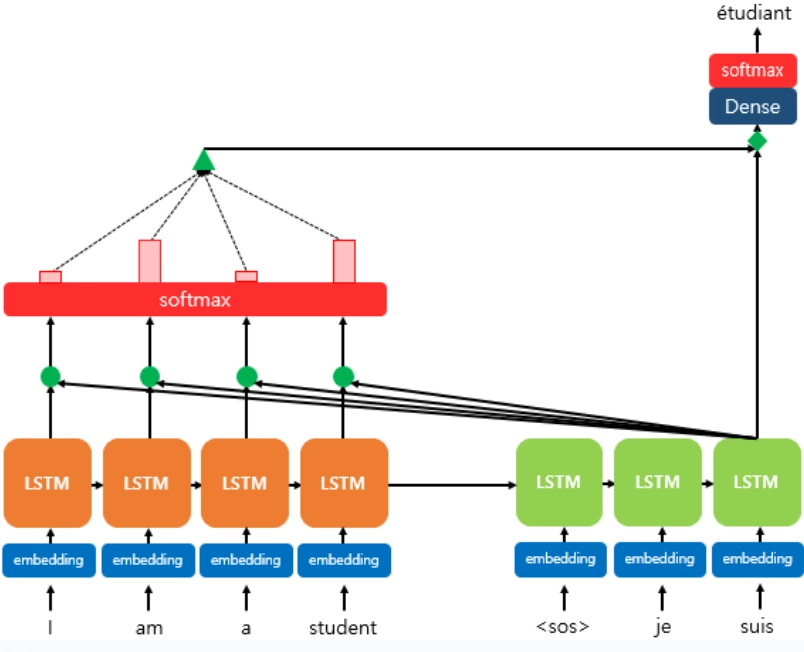  
- attention: 결과 생성 시 현재 시점에서 가장 중요한 부분에 더 높은 가중치 부여 -> 중요한 정보에 더 집중. Seq2Seq와 달리 **출력시점마다 새로운 문맥벡터**를 동적 계산 -> **병렬화**
    - 과정: 입력을 벡터 형태로 변환 -> 단어별 중요도 계산 -> 중요도에 따른 입력 정보 조합
    - 장점
        - **시간 경과(순서적 거리)에 대한 유연성**: 모든 단어에서 다른 모든 단어로 직접 연결 가능 -> 정보 손실 X
        - **공간에 대한 유연성**: 이미지의 모든 픽셀이 다른 모든 픽셀과 직접 연결 -> 한 번에 전체 이미지의 전역적 관계 학습 가능
        - **병렬화**: self-attention에서 문장 내 모든 단어의 관계를 한번에 독립적으로 계산

## Attention is All You Need
- Google Brain의 논문으로, Transformer 구조를 처음 발표
- 기존의 RNN 기반 모델들의 한계를 극복하기 위해 순차적 계산 구조를 아예 제거하고,인코더부터 디코더까지 오직 Attention만을 사용하는 모델 제시
- 성공적인 모델링에 Recurrence 및 Convolution이 필수가 아님을 증명

### [Transformer란?]
- 개념: RNN의 순차적인 계산 방식을 완전히 버리고, **오직 어텐션만으로 문장의 의미와 구조를 파악**하는 모델
- 핵심 기술
    - **Self-Attention**: 문장 안에서 각 단어들 사이의 관계의 중요성을 한 번에 파악
    - **Multi-Head Attention**: 셀프 어텐션을 여러 개의 머리로 동시에 서로 다른 관점에서 실행
    - **Positional Encoding**: 단어의 위치 정보를 벡터에 추가 -> 각 단어가 문장의 몇 번째 위치에 존재하는지 파악

# **Self-Attention**
## Query, Key, Value
- Query: 지금 당장 내가 알고싶거나 초점을 맞추고 있는 대상
- Key: 검색 대상이 되는 모든 정보들이 달고있는 이름표
- Value: 키와 한 쌍으로 묶여있는 실제 내용물. 쿼리와 키의 관련도 계산이 끝나고, 가장 관련성이 높다고 판단된 키가 선택되면, 모델은 그 키에 해당하는 밸류를 가져와 사용

## 기존 Cross-Attention vs Self-Attention
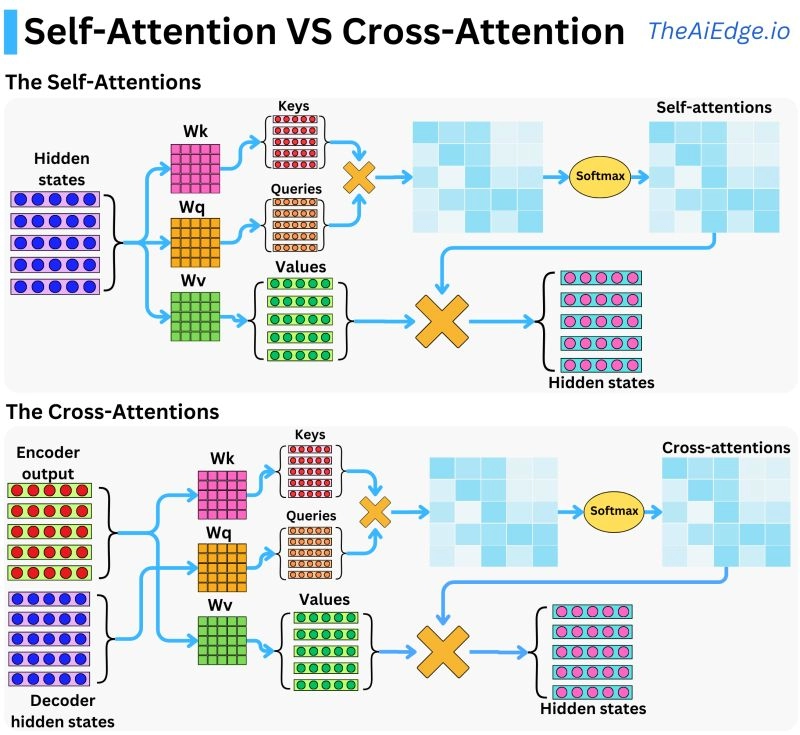  

| 구분 | **Cross-Attention** | **Self-Attention** |
|---|---|---|
| 핵심 개념 | **다른 문장**을 참고하여 정보 생성 | 문장 **자체 내부 관계** 분석 |
| Query / Key-Value 출처 | 서로 **다른** 시퀀스 | **같은** 시퀀스 |
| 목적 | 입력 정보를 참고해 출력 생성 | 문맥 이해 및 단어 간 관계 파악 |
| 동작 방식 | Decoder가 Encoder 출력 참고 | 각 단어가 문장 내 다른 단어들을 참고 |

### [Cross-Attention의 과정]
1. 쿼리 만들기: 지금까지 생성된 단어들을 보고 디코더가 현재 상태를 하나의 벡터(쿼리)로 요약
2. 키, 값 불러오기
3. 유사도 계산: 디코더의 쿼리와 인코더의 각 키 사이의 관련성 계산 -> 이 값이 이 단어를 얼마나 참고할지 결정 -> 점수를 softmax로 정규화해서 전체가 1이 되도록 가중치로 변환
4. Weighted Sum: 인코더의 값들을 3의 가중치로 섞어 하나의 벡터 생성
5. 디코더가 다음 단어 예측

### [Self-Attention의 과정]
1. 단어 프로필 만들기: 각 단어의 고유한 특징을 담은 벡터 임베딩
2. 단어 간 관계 점수 계산
3. 중요도 배분: 특정 단어를 이해하는 데 다른 단어들이 각각 얼마나 중요한가?
4. 새로운 벡터 생성: 가중치를 바탕으로 문맥이 완벽하게 반영된 새로운 프로필 생성

## Scaled Dot-Product Attention
### [Dot-Product Attention]
- 개념: 어텐션 점수를 계산하는 가장 기본적인 방법으로, *쿼리와 키 벡터를 내적하여 유사도 계산*
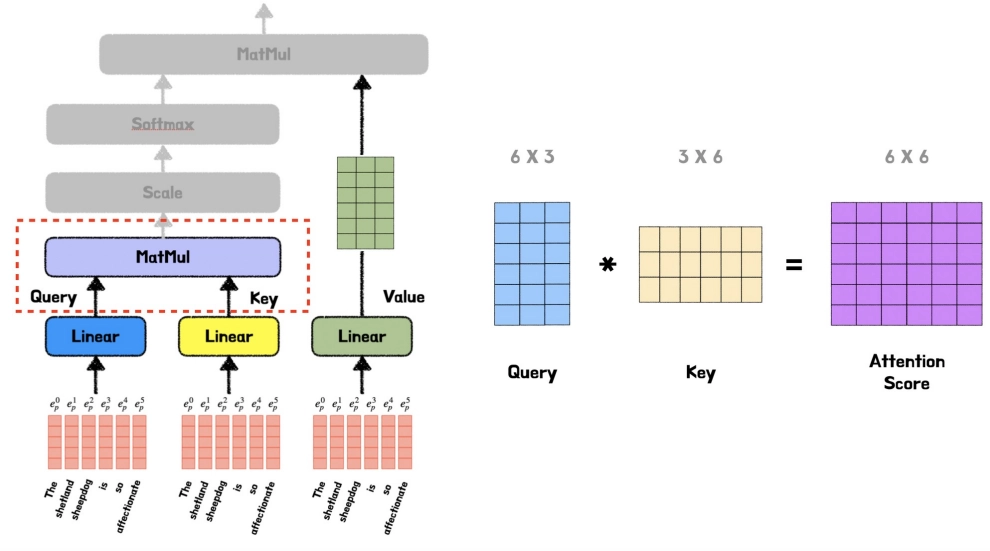  
- 과정: 쿼리 벡터와 모든 키 벡터를 각각 내적 -> 계산된 값에 소프트맥수 함수 적용하여 총합이 1인 Attention Weight 산출 -> 이 가중치를 밸류 벡터에 곱해 최종 결과값 계산
- 문제점: **어텐션 점수의 극단화**
    - **벡터 차원이 커질수록 내적값이 양극화** -> 극단적인 값이 소프트맥스에 입력 시 특정 단어에 확률 과도하게 집중 -> **기울기 소실 문제** 발생 가능

### [Scaled Dot-Product Attention]
- 기존의 Dot-Product Attention 과정에서 내적 진행 후 **스케일링 과정**을 통해 값의 크기를 맞춤(**계산된 값을 $\sqrt{d_k}$로 나눔**) -> 소프트맥스 함수 적용, 밸류 벡터에 곱해 최종 결과값 계산
- 내적값이 과도하게 증가하는 것 방지 -> 소프트맥스 함수의 안정적인 학습
- 이를 통해 Cross-Attention은 현재 생성 중인 단어가 **어떤 단어에 집중해야하는지 반영한 문맥벡터**를, Self-Attention은 문장 내 **다른 단어들과의 관계를 반영한 문맥적 표현**을 얻는다.

# Multi-Head Attention
- 개념: Transformer가 토큰들 사이의 관계를 파악하고, 문맥 정보를 반영하여 더 정확한 출력을 만들 수 있도록 도와주는 핵심 구조
    - Masked Multi-Head Attention: 아직 생성되지 않은 미래 단어를 가리고, 현재까지 생성된 단어들만 참고
- 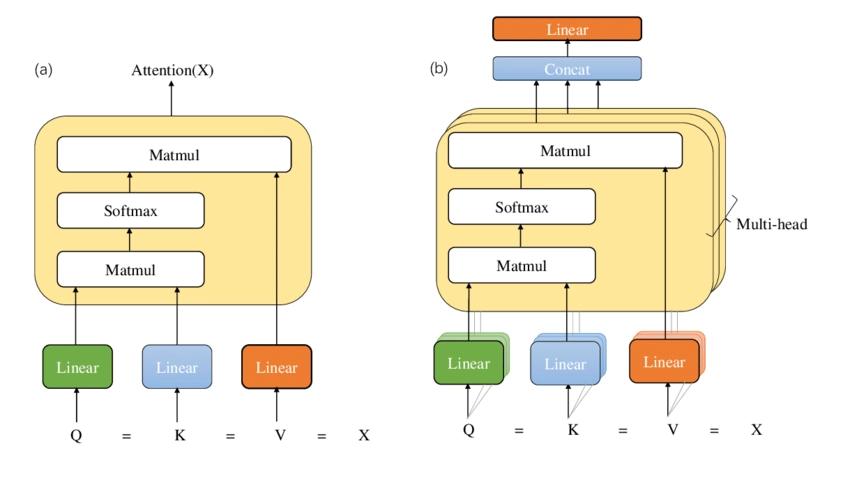
    | 구분 | Single-Head Attention | Multi-Head Attention |
    |---|---|---|
    | 개념 | 하나의 Attention만 사용 | 여러 개의 Attention을 **병렬로** 사용 |
    | 가중치 행렬 | 하나의 $(W^Q, W^K, W^V)$ 사용 | Head마다 서로 다른 $(W^Q, W^K, W^V)$ 사용 |
    | 입력 처리 방식 | 전체 벡터를 한 번에 처리 | **벡터를 여러 부분으로 나누어 처리** |
    | 예시 구조 | 512차원 → 하나의 Attention 계산 | 512차원 → 64차원 × 8 Head |
    | 계산 방식 | Attention Score 1번 계산 | 여러 Head에서 병렬 계산 |
    | 한계 | 가중 평균 사용 -> 중요한 관계 놓칠 가능성 |  |

### [Multi-Head Attention 작동방식]
1. **분할** (Projection) - 8명의 헤드에 단어 벡터 할당: 특정 단어 벡터를 8개의 작은 벡터 그룹으로 투영 -> 8세트의 서로 다른 가중치 행렬 곱함
2. **병렬 어텐션** 계산 - 각 헤드들이 각자 분석 수행: 병렬로 Scaled Dot-Product Attention 계산
    - 점수 계산 -> 크기 조절 -> 가중치 변환 -> 가중합
    - 결과 = 헤드# 관점에서 문맥을 이해한 64차원의 결과벡터 Attention_Output_#
3. **결합 및 최종 투영**: 각자의 분석 결과(총 8개)를 하나로 합침
    - 8개의 64차원 벡터들을 순서대로 이어붙여 하나의 거대한 512차원 벡터 생성
    - 또다른 가중치 행렬을 곱해 최종 투영

# **Transformer 전체 아키텍처**
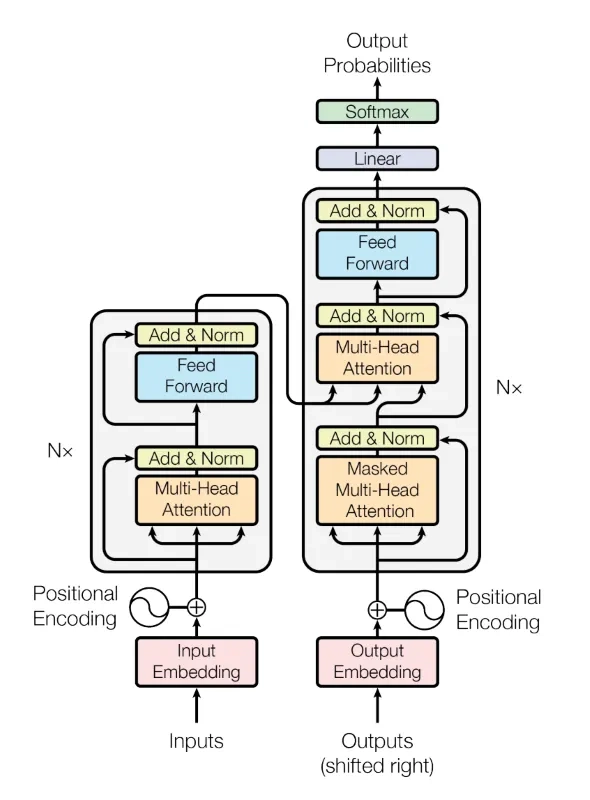  
## 트랜스포머의 전처리 단계
1. 토큰화: 입력 텍스트를 모델이 처리할 수 있는 단위(토큰)으로 나누는 첫번째 단계
    - 대부분의 경우 각 토큰은 하나의 단어, 문장 부호 별도
    - 일부 단어는 하나 이상의 토큰으로 나뉠 수 O(ex: doesn't -> does, n't)
2. 임베딩: 각 토큰을 숫자 벡터로 변환
    - 단어의 의미를 공간적으로 표현 -> 의미가 유사한 단어는 유사한 숫자로 변환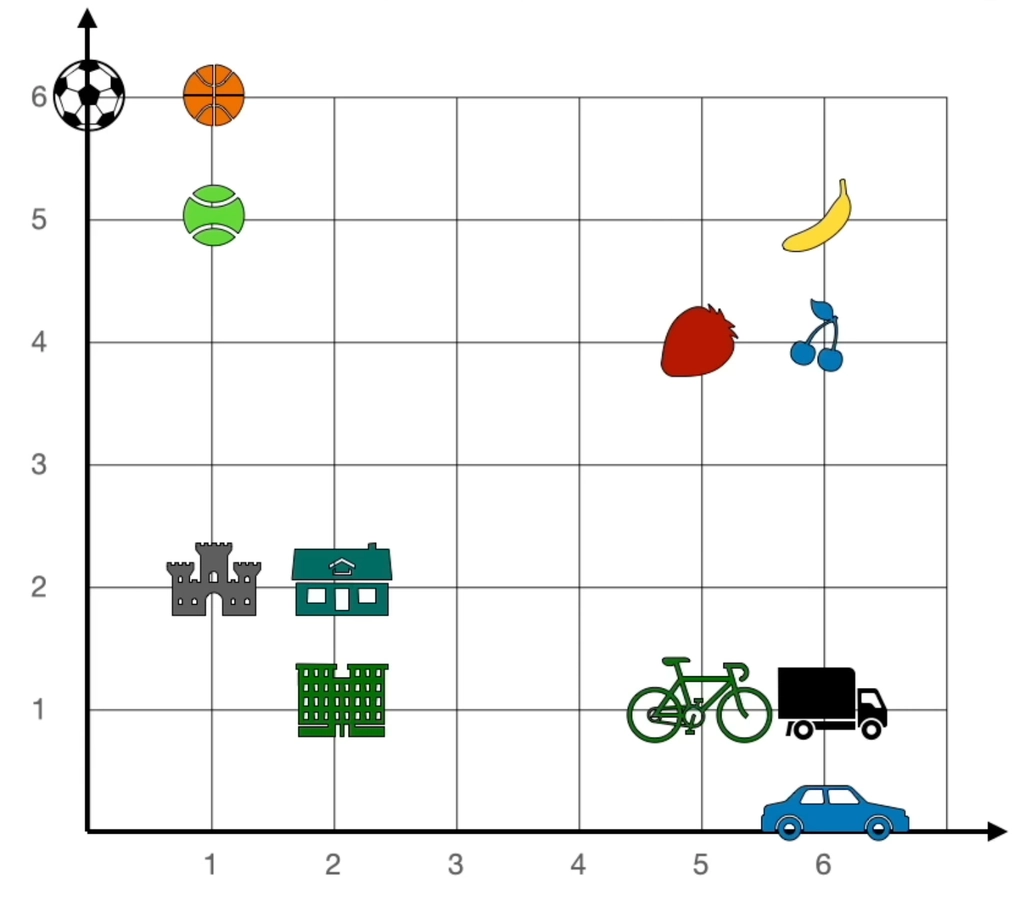  
    -> 단어에 대한 기본 속성 제공
3. Positional Encoding: 단어들의 순서 정보를 임베딩 벡터에 추가
    - 트랜스포머는 모든 단어를 병렬로 한 번에 처리 -> 순서 X
    - 각 단어의 임베딩 좌표에 일관된 순서를 따르는 다른 순서를 추가하여 순서 정보 기록 -> 같은 단어라도 문장에서의 위치에 따라 좌표를 다르게 부여

## 트랜스포머의 인코더와 디코더
### [Encoder]
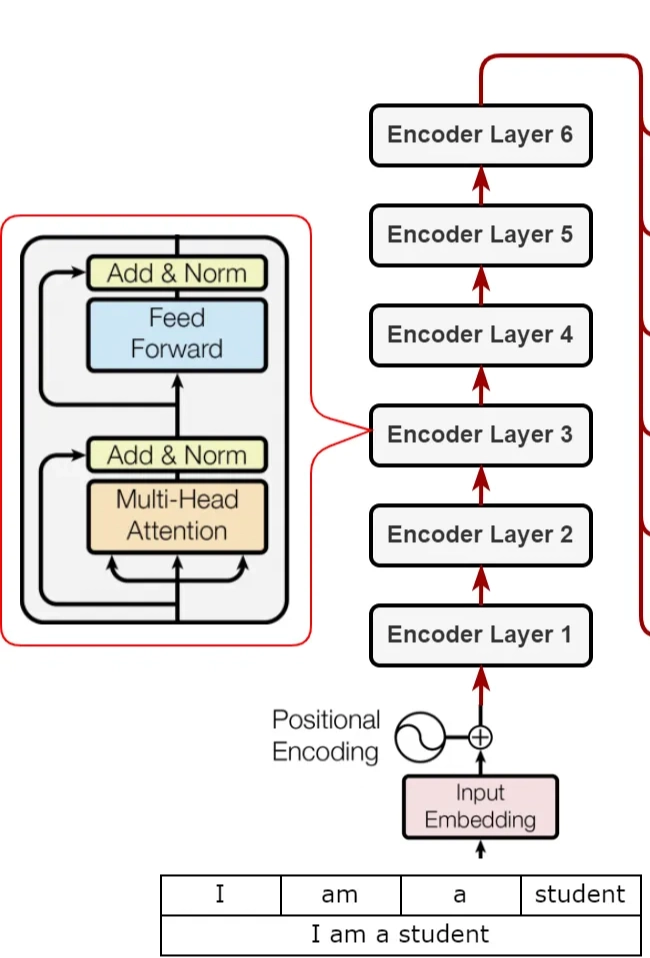  
- 역할: 입력 문장을 이해하고 **요약된 의미 벡터로 변환**
- 전처리 과정 + **인코더 레이어**(Multi-Head Attention + Feed-Forward)
- **Feed-Forward** Layer: 입력 벡터의 차원을 확장하고 비선형 변환을 적용하여 새로운 표현을 생성하는 신경망 구조. **MLP가 2층으로 완전 연결**된 구조 -> 어텐션에서 결정한 단어에 대해 심층 분석
- Residual connections(잔차 연결): 입력 값을 그대로 출력에 더해주는 것으로, 여러 층이 쌓이면 발생할 수 있는 기울기 소실/폭주 현상을 방지하기 위해 입력-출력 경로를 축약한 것
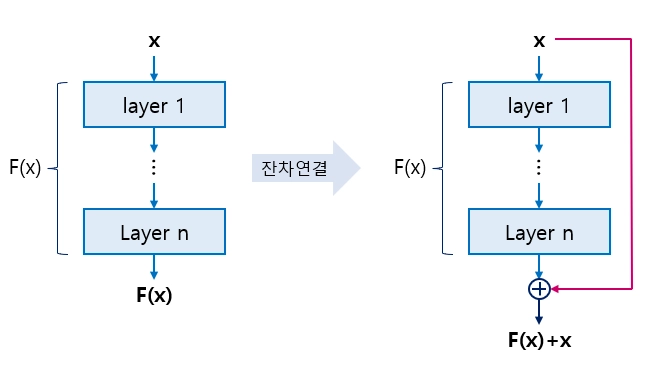  
- Layer Normalization(층 정규화): 입력벡터의 평균과 분산을 사용해 정규화 -> 각 피쳐의 중요도를 동등하게 하여 학습 안정화, 모델이 빠르게 수렴

### [Decoder]
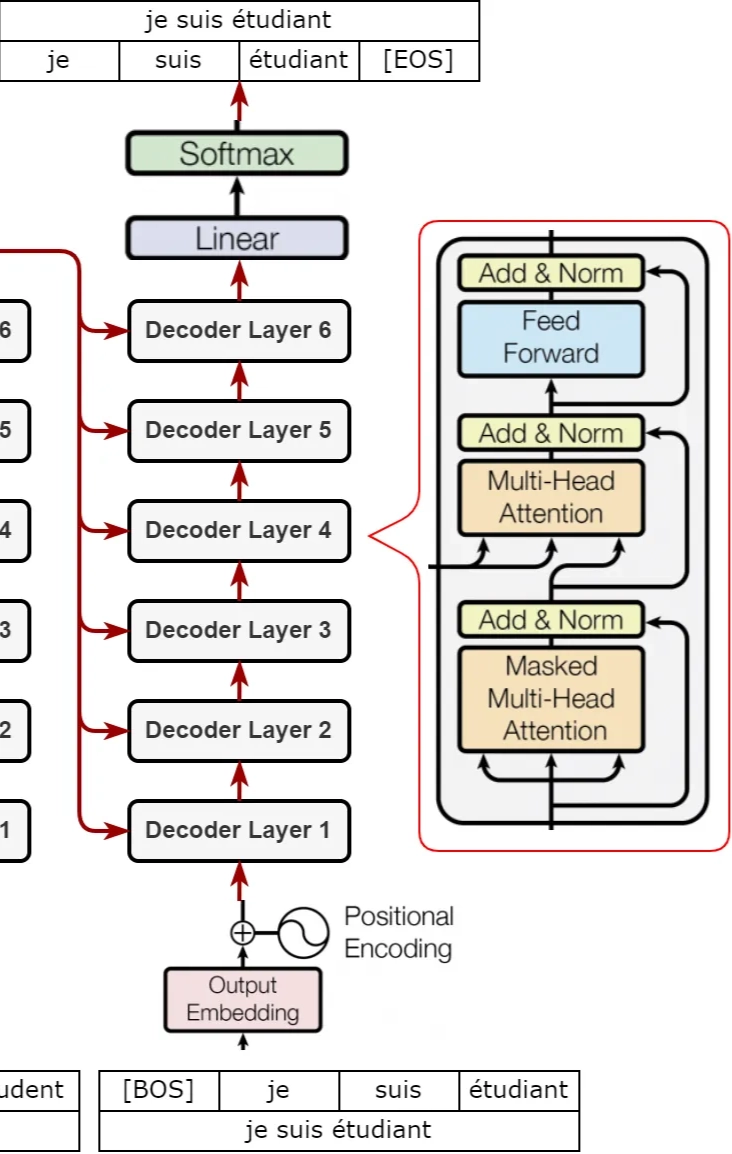  
- 역할: Encoder가 분석한 입력 문장의 의미 벡터를 받아서 **출력 문장을 순차적으로 생성**
- 전처리 과정 + **디코더 레이어**(Masked Multi-Head Attention + Encoder-Decoder Multi-Head Attention (Cross-Attention) + Feed-Forward Layer) + 선형 레이어 + 소프트맥스 레이어
- **Masked Multi-Head Attention**: 미래 시점의 단어 정보를 참고하지 못하도록 **마스크를 적용**(미래 토큰 어텐션값 = 0)하는 어텐션 메커니즘 -> 과거 정보만 참고해 다음 단어를 예측하도록 강제
- **Encoder-Decoder Attention (Cross-Attention)**: 디코더가 인코더의 출력(Context)을 참고하면서 현재 생성 중인 단어를 입력 문장의 의미와 연결하는 과정 -> 디코더가 입력 문장 중 어떤 부분에 주목해야하는지 학습
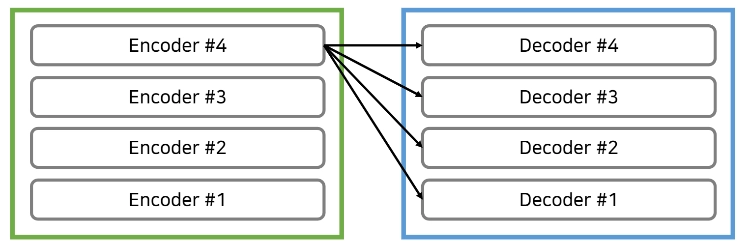
